# Seaborn

Seaborn is a higher-level library built on top of Matplotlib. It's specifically designed for creating more visually appealing and informative statistical graphics with less code. It's excellent for exploring relationships between variables. 

**Learning Objectives**
- Explore multivariate relationships using pairplot, jointplot, and heatmap.
- Use Seaborn themes, contexts, and color palettes to control plot aesthetics.
- Apply statistical overlays and models (regplot, lmplot) and interpret confidence intervals.
- Work with built-in datasets (e.g., iris) and understand tidy data requirements for Seaborn.
- Combine Seaborn with Matplotlib for fine-grained customization and saving figures.
- Learn to choose appropriate plot types and interpret visualizations to communicate insights.


 

In [1]:
import numpy as np
import pandas as pd

In [ ]:
# %pip install matplotlib   ### install upon need; comment out after done
import matplotlib.pyplot as plt

In [3]:
### Seaborn requires Matplotlib as a dependency.

# %pip install seaborn   ### install upon need; comment out after done
import seaborn as sns
# Set the Seaborn style for all plots 

sns.set_theme(style="darkgrid")   ### other styles include "whitegrid", "dark", "white", and "ticks"

## The Iris Dataset

Seaborn comes with several built-in datasets that are useful for practice and examples. 

In [2]:
### load the built-in 'Iris' dataset
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Pair Plot

The pairplot function creates a grid of plots, showing relationships between all pairs of variables in a DataFrame. This is a great tool for initial data exploration. 

The diagonal plots in a pairplot are histograms showing the distribution of each variable, while the off-diagonal plots are scatter plots showing the relationship between two variables, colored by a categorical variable (if specified by hue). 

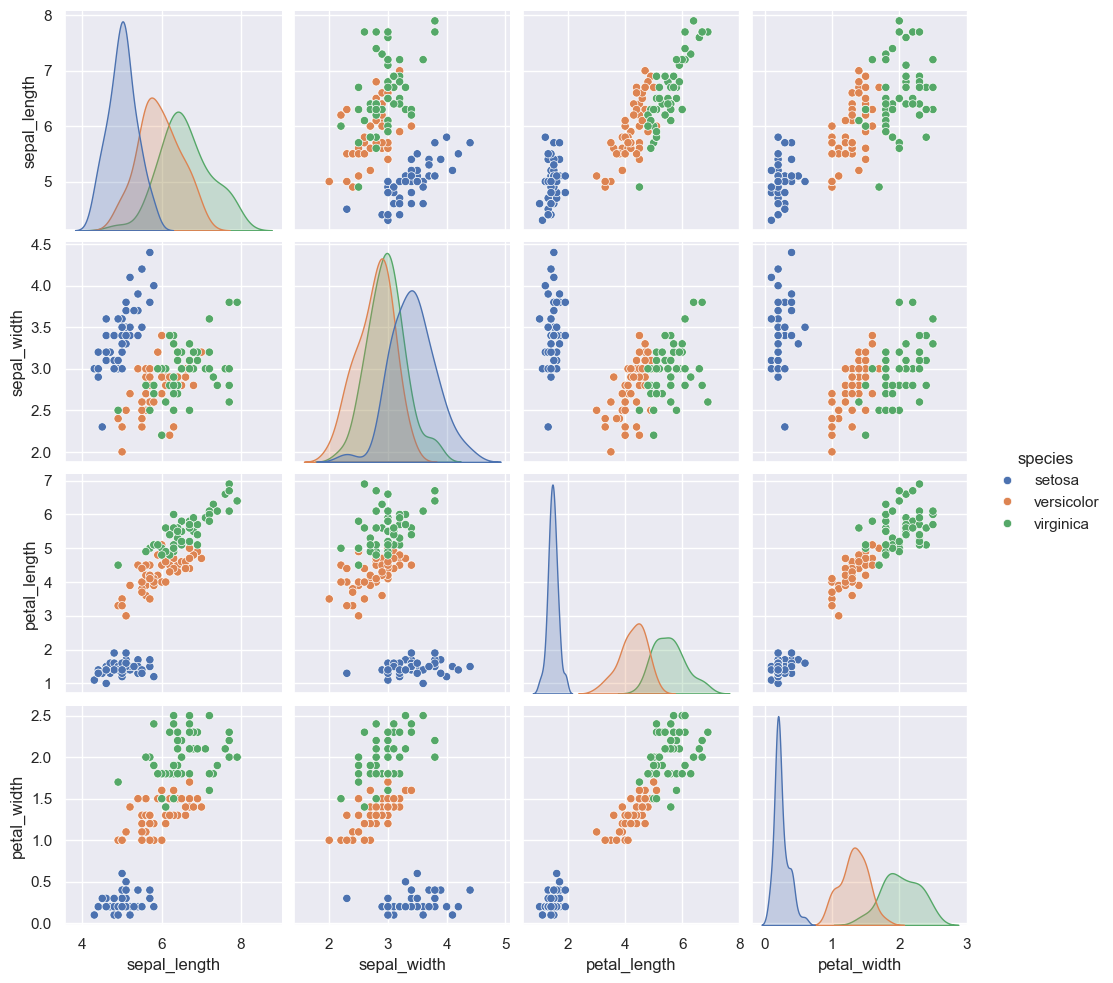

In [4]:
sns.pairplot(iris, hue='species')
# sns.pairplot(iris, hue='species', markers=["o", "s", "D"])

## Relational Plots (Line and Scatter) 

Seaborn's **`relplot`** function provides a unified way to create line and scatter plots with rich semantics (color, style, size). 



In [5]:
### the tips dataset
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


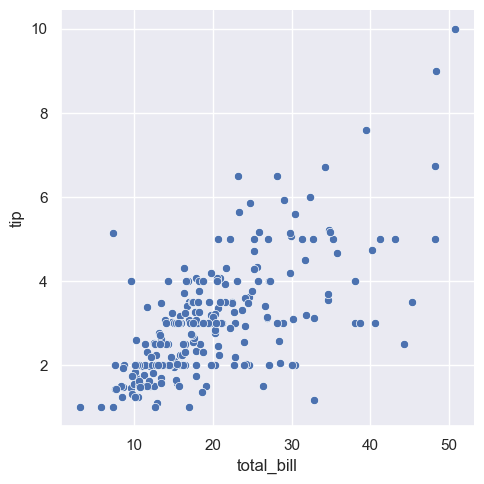

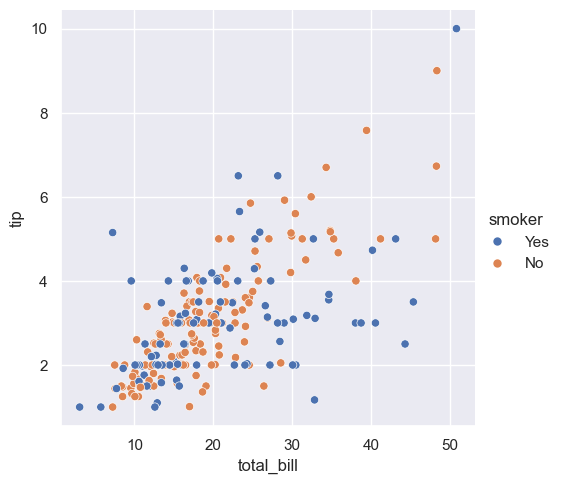

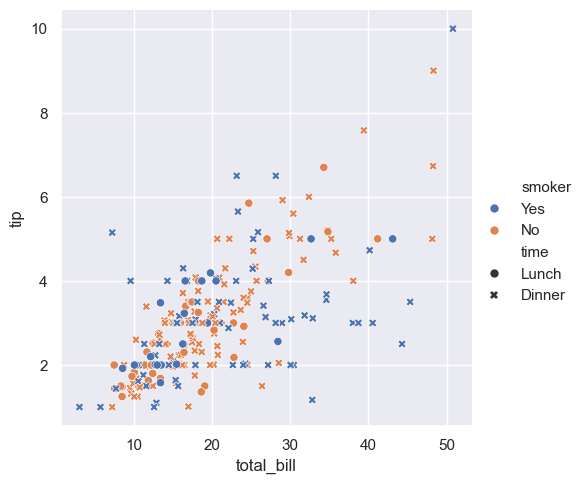

In [15]:
sns.relplot(x='total_bill', y='tip', data=tips)
sns.relplot(x='total_bill', y='tip', hue='smoker', data=tips) 
sns.relplot(x='total_bill', y='tip', hue='smoker', style='time', data=tips)


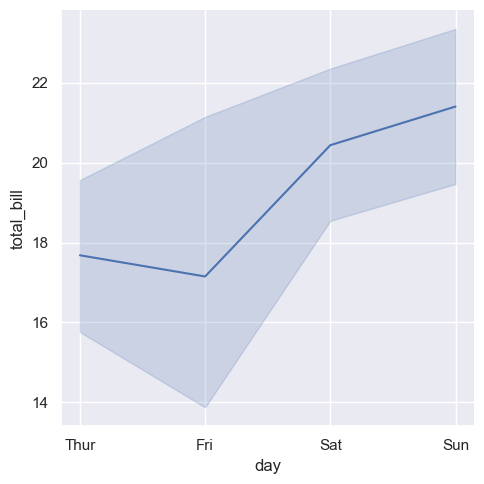

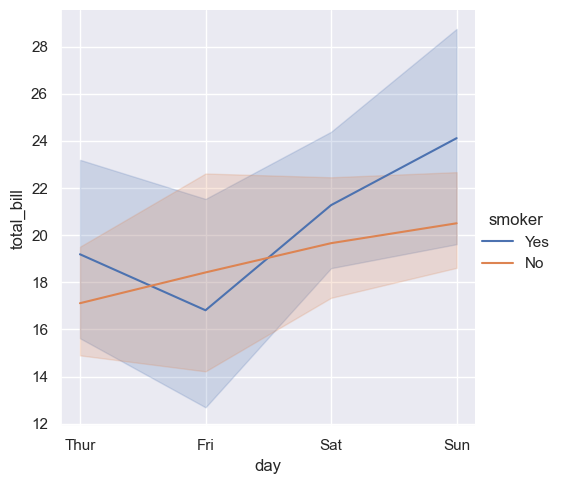

In [ ]:
### line plot
### hue is good for categorical variables
### style is good for categorical variables with few unique values

sns.relplot(x='day', y='total_bill', kind='line', data=tips)
sns.relplot(x='day', y='total_bill', hue='smoker', kind='line', data=tips)

<Axes: xlabel='total_bill', ylabel='tip'>

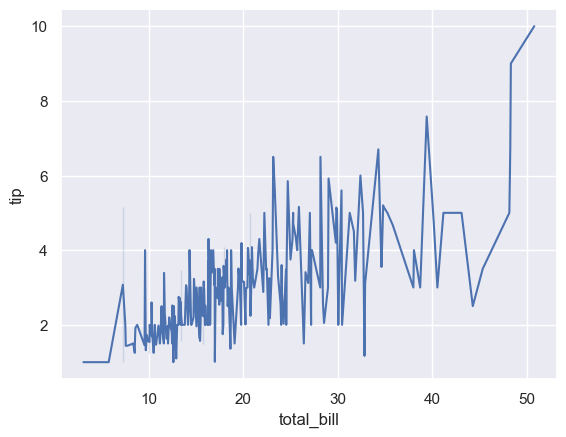

In [20]:
### another way to create a line plot

sns.lineplot(x='total_bill', y='tip', data=tips)

## Categorical Plots

Seaborn offers several functions for visualizing categorical data, such as 
- bar plots, 
- box plots, and 
- violin plots.

### Bar Plot

<Axes: xlabel='day', ylabel='total_bill'>

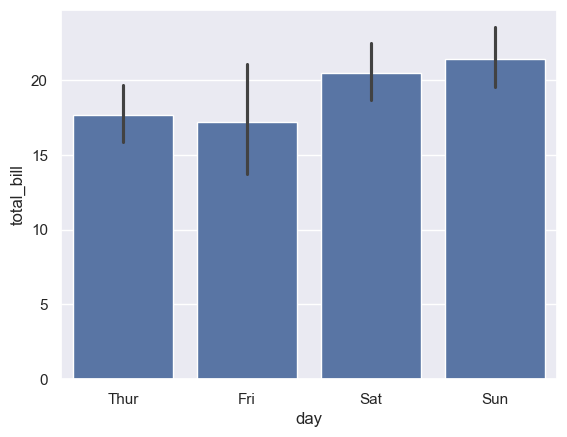

In [35]:
sns.barplot(x='day', y='total_bill', data=tips)

### Box Plot

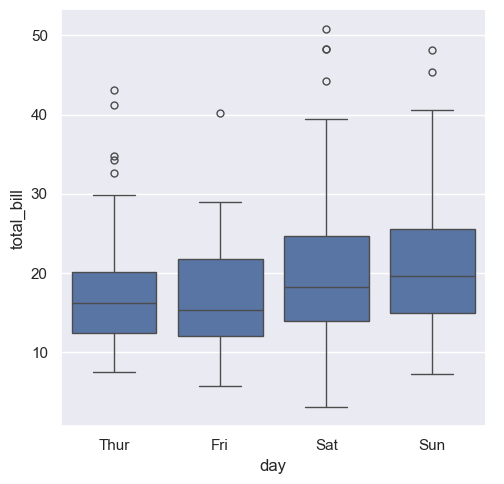

In [36]:
### box plot with catplot and kind='box'

sns.catplot(x='day', y='total_bill', kind='box', data=tips)

<Axes: xlabel='day', ylabel='total_bill'>

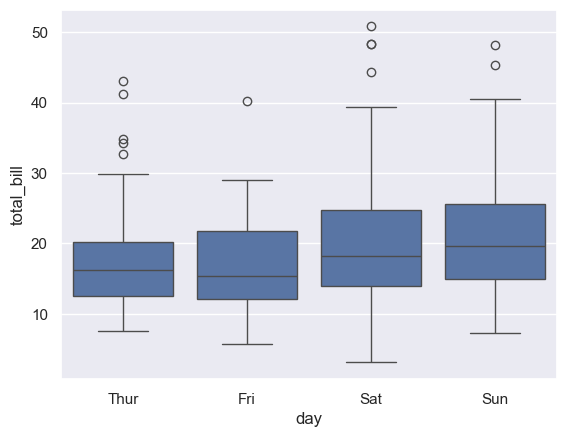

In [37]:
### box plot with boxplot()

sns.boxplot(x='day', y='total_bill', data=tips)

<Axes: xlabel='day', ylabel='total_bill'>

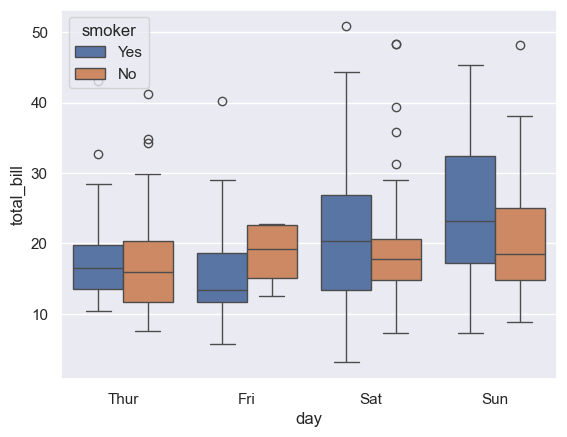

In [38]:
### box plot with hue

sns.boxplot(x='day', y='total_bill', hue='smoker', data=tips)

## Heatmaps

A heatmap is a graphical representation of data where the individual values contained in a matrix are represented as colors. It's great for visualizing correlation matrices. 

In [ ]:
# corr = iris.corr()          ### dataset must be numeric
                            ### ValueError: could not convert string to float: 'setosa'

iris.corr(numeric_only=True)


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


Text(0.5, 1.0, 'Heatmap of Iris Dataset Correlation Matrix')

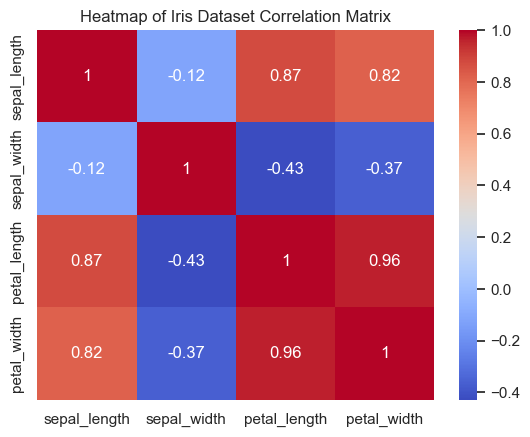

In [48]:
### create a heatmap
sns.heatmap(iris.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Heatmap of Iris Dataset Correlation Matrix')

In [50]:
tips.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<Axes: >

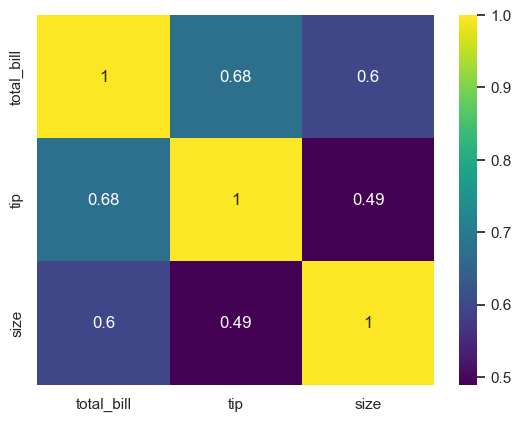

In [53]:
sns.heatmap(tips.corr(numeric_only=True), annot=True, cmap='viridis')

<Axes: >

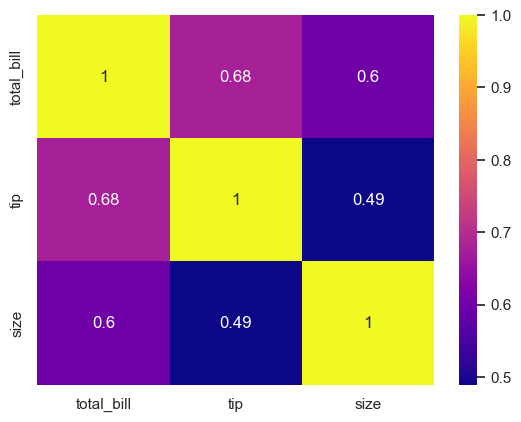

In [54]:
sns.heatmap(tips.corr(numeric_only=True), annot=True, cmap='plasma')